<a href="https://colab.research.google.com/github/jasminl/adaptics/blob/master/incremental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Incremental generative learning

In [37]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
def attempt_target(max_trial, bias, target, approx_threshold, inference_var):
  """ Main learning and inference function """
  for i in range(max_trial):

    # Generate new bias term
    new_bias = np.random.normal()

    loc = 0 + sum (bias) + new_bias

    # Inference
    y = np.random.normal(loc, inference_var)
    if np.abs(y - target) < approx_threshold:
      return True, new_bias, i
  return False, None, max_trial


In [ ]:
# Key parameters
approx_threshold = 0.1  # How close we need to be to the target
inference_var = 0.1  # Variance of the genrative function
num_reps = 100

Run as a single process

Run as multiple attempts with incremental targets

In [ ]:
target = 3
max_trial = 10

def multi_process(target):
  iter_distr = []
  bias_length = []

  split  = [1/3, 1/2, 3/4, 1]  # Last one always 1, the original goal

  for i in range(num_reps):

    bias = []  # Reset bias

    total_per_iter = 0
    for s in split:
      new_target = s * target
      success, new_bias, iter = attempt_target(max_trial, bias, new_target,
                                             approx_threshold, inference_var)
      total_per_iter += iter
      if new_bias is not None:
        bias.append(new_bias)

  #  print('Goal: ', new_target, ', bias: ', bias, 'iter: ', iter,
  #        'Success' if success else 'Failure')

  # Check if the original target is reached, if so, track num of iterations
    if success:
      iter_distr.append(total_per_iter)
      bias_length.append(len(bias))
  return iter_distr, bias_length

successful_runs, bias = multi_process(target)
max_num_trials = max(successful_runs)
print('Number successes: ', len(successful_runs), ', max num runs: ', max_num_trials)
#print(iter_distr)
#print(bias)

In [27]:
# For a fair comparison, allow as many trials as the sum of all trials in the
# decomposed case
max_trial = max_num_trials

# Step learning function: if above num of trials, learn instantly, else no learn
learn_threshold = 15  # The number of trials needed for a snapshot learning
def plearn_step(n_trial, learn_threshold):
  if n_trial > learn_threshold:
    return True
  return False

def single_process(target, plearn_fct):
  iter_distr = []
  bias_distr = []
  bias = []
  for i in range(num_reps):
    success, new_bias, iter = attempt_target(max_trial, bias, target,
                                             approx_threshold, inference_var)

    if success is True:
      if plearn_fct is None or plearn_step(iter, learn_threshold) is True:
        #print('Iter ', iter)
        iter_distr.append(iter)
        bias_distr.append(new_bias)

  return iter_distr, bias_distr

successful_runs, successful_bias = single_process(target, plearn_step)
print('Number of successes: ', len(successful_runs))

Number of successes:  22


Some questions
- catastrophic forgetting
- multi-task
- target noise Vs fast learning
- inference noise Vs fast learning
- removing/merging priors
- task decomposition
- overall progress metric


Some conclusions:
- When the inference variance is wide, making the responses uncorrelated with the biases, then, there is no advantage of decomposing a task. So the variance in inference must be somewhat low. I.e. the generated response must be correlated in some way.

0.01703709040687941


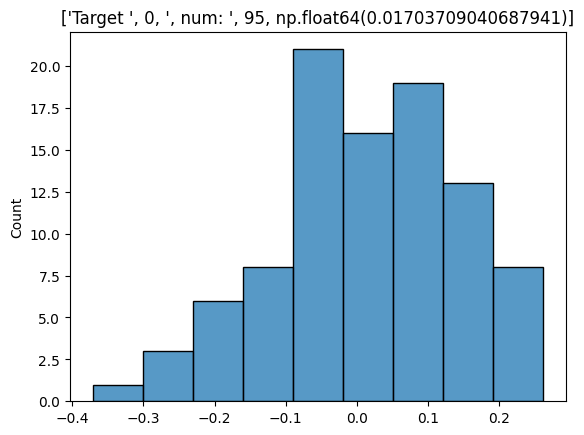

0.007472722873597114


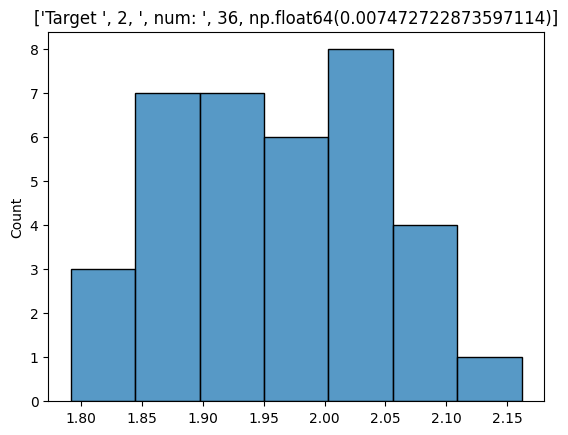

0.011498050581366053


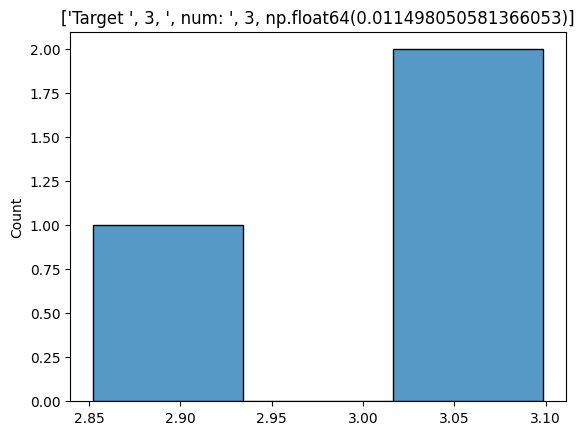

In [57]:
# Measure bias and variance for different targets

for target in [0, 2, 3]:
  successful_runs, successful_bias = single_process(target, plearn_fct = None)
  print(np.var(successful_bias))
  plt.figure()
  sns.histplot(successful_bias)
  plt.title(['Target ', target, ', num: ', len(successful_bias), np.var(successful_bias)])
  plt.show()


So it looks like the variance observed here is not dependent on eccentricity. Rather it depends on the approximation threshold and the variance of the gaussians used to generate the priors and generate the outputs.

=> This should be confirmed analytically.

In [ ]:
# Show usage of conditional entropy

